In [1]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
import pickle
import datetime
from tqdm import tqdm
from matplotlib.pyplot import cm
import numpy as np
from hardware.timetagger_counter import HWRecorderMode
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!

In [2]:
def setup_autoapproach():
    #configuration of autoapproach settings
    # for HFAmpl signal

    threshold = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_SETP_DISP')) / 1e7
    spm._dev.aap.setAApThreshold(threshold)

    # dF     8
    # HFAmpl       13
    input_signal = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_INPUT'))
    threshold_cond = 1 if input_signal==13 else 0        
    spm._dev.aap.setAApStopCondition(threshold_cond) # [0, 1] >threshold/<threshold
    spm._dev.aap.setAApStepsPerApproach(0)

    spm._dev.aap.setAApAproachMode(1) # [0, 1] Ramp/Loop
    spm._dev.aap.setAApModeAfter(0) # [0, 1, 2] On/Retract/Off

def get_pos(reps=5):
    pos = 0
    for i in range(reps):
        pos = pos+ spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return pos/reps

def go_into_contact():
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_AAP_CTRL'), 1, 0)
    while not spm.is_probe_landed():
        time.sleep(0.001)
    time.sleep(0.5)
        
def do_lift_off(lift_off_height):
    pos = get_pos()
    new_pos = pos - lift_off_height
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_LOOP_ON'), 0, 0)
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), new_pos*1e12, 0)
    return pos

def _grabASCData(chnNo, bufSize):
    while True:
            # Wait until buffer is full
        if spm._dev.base.waitForFullBuffer(chnNo) != 0:
                break
    buffer = spm._dev.base.getDataBuffer(chnNo, 0, bufSize)
    values = buffer[3][:]
    meta = buffer[4]
    phys_vals = []
    unit = spm._dev.base.getUnitVal(meta)
    scaling = 1
    if 'Milli' in unit:
        scaling = 1e-3
    for val in values:
        phys_vals.append(spm._dev.base.convValue2Phys(meta, val)*scaling)
    return np.mean(phys_vals)    
    
def get_spm_channel_data(channel="CHANADC_AFMAMPL"):
    """Look in to the header file asc500.h for all the channel names"""
    spm._dev.base.configureChannel(11, # any Number between 0 and 13.
                            spm._dev.base.getConst('CHANCONN_PERMANENT'), # How you want to the data to be triggered
                            spm._dev.base.getConst(channel), #The Channel you want to get the data from
                            1, # 0/1 -  if you want to switch on averaging
                            1e-3) # Scanner sample time [s]
    spm._dev.base.configureDataBuffering(11, 256) # chNo = same as above; bufSize = Buffersize.
    # MAKE SURE BUFFER SIZE IS GREATER THAN 128 FOR TIME TRIGGERED DATA
    return _grabASCData(11, 256)

def setup_counter(laser_pulses, max_sweeps):
    ret_val = afm_scanner_logic._counter.configure_recorder(
                mode=HWRecorderMode.GENERAL_PULSED,
                params={'laser_pulses': laser_pulses,
                        'bin_width_s': podmrlogic.bin_width_s,
                        'record_length_s': podmrlogic.record_length_s,
                        'max_counts': int(max_sweeps)} )
    
def run_measurement():
    afm_scanner_logic._counter.start_recorder(arm=True)
    #Start pulsed measurement
    afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_on()
    # obtain pulsed measurement
    pulsed_meas = afm_scanner_logic._counter.get_measurements()[0] # this is the blocking statement
    afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_off()
    return pulsed_meas

def multiple_formatter(denominator=2, number=np.pi, latex='\pi'):
    def gcd(a, b):
        while b:
            a, b = b, a%b
        return a
    def _multiple_formatter(x, pos):
        den = denominator
        num = np.int(np.rint(den*x/number))
        com = gcd(num,den)
        (num,den) = (int(num/com),int(den/com))
        if den==1:
            if num==0:
                return r'$0$'
            if num==1:
                return r'$%s$'%latex
            elif num==-1:
                return r'$-%s$'%latex
            else:
                return r'$%s%s$'%(num,latex)
        else:
            if num==1:
                return r'$\frac{%s}{%s}$'%(latex,den)
            elif num==-1:
                return r'$\frac{-%s}{%s}$'%(latex,den)
            else:
                return r'$\frac{%s%s}{%s}$'%(num,latex,den)
    return _multiple_formatter

class Multiple:
    def __init__(self, denominator=2, number=np.pi, latex='\pi'):
        self.denominator = denominator
        self.number = number
        self.latex = latex

    def locator(self):
        return plt.MultipleLocator(self.number / self.denominator)

    def formatter(self):
        return plt.FuncFormatter(multiple_formatter(self.denominator, self.number, self.latex))

### Little manual

1. Input the values below which were measured before. <br>
2. Make sure that the AWG gets the correct trigger signal at "Trig0 In" (same frequency as the tip or signal on the sample)<br>
3. Position the tip somewhere with a strong gradient (lock-in to tip) or a strong AC signal amplitude (lock-in to periodic sample signal) <br>
4. For a first test run "t0 sweep". Make sure that you have chosen reasonable trigger levels: trig_0 must be larger than trig_1 by about 200 mV; A_exc can be adjusted if needed: larger gradient signal for tip lock-in: Make sure that the values fit to the values in Daisy including set point etc. Otherwise the tip can get damaged!; tau should be equal or a bit smaller than T2 of the tip. 
5. Copy the file name and folder path in "Plot Phase dependencies". Plot "t0 sweep with A_exc". The Plot should show a smooth oscillation of the phase with a period corresponding to the inverse oscillation frequency of the tip/ sample signal.
6. Choose the t0 with the largest phase (could have negative sign). 
7. Optional: One can play with the trigger level to reduce t0 in order to save a significant amount of time in a 2D scan. One can do it by hand in "t0 sweep" or use "Trigger level sweep to minimize the t0": choose t0 as small as possible here.
8. Careful: Sometimes the phase plots don't look like a nice oscillation because there can be an issue with the phase unwrapping which can be activated or deactivated. It's best to keep it activated and to play with the trigger level by hand until a nice oscillations is measured. 
9. Input t0 and the trigger levels as well as all other needed values to "Gradiometry XY Scan".
10. Plot the data in "Data analysis" by copying and pasting the file path and file name.
11. With "Control of Keithley 6487" one can set a constant voltage to generate a constant field for tip lock-in gradiometry.

#### Define general measurement params

In [3]:
#measurement parameters
laser_power_voltage = 0.0 #podmrlogic.laser_power_voltage

#Driving information for the first LO (SMBV)
target_freq_0 = 3.14903e9 # Hz
LO_freq_0 = target_freq_0 + 100e6 # Hz
power_0 = -9 # dBm
pi_pulse = 240e-9 # s  

#additional information for save tag
tip_name = 'A-T16-25'
sample = 'J5810-Nils'
temperature = ''
b_field = '250mVpp_lock_in'
contact = 'OOC'
res_freq = spm._dev.afm.getTFExcicationFrequency()
print(res_freq)
#res_freq = 195e3 # lock in measurement to voltage source
extra = f'{res_freq/1e3}kHz_'+b_field

5710.519


In [4]:
print('test')

test


#### Trigger level sweep to minimize the t0

In [23]:
wait_bw_TF_set = 5
Aexc = spm._dev.afm.getTFExcitationAmplitude()

lift_off_height = 20e-9 # m

tau = 2e-6 # s

trig_separation = 200 # mV
trig0_start = 200 # mV
trig0_stop = 400 # mV
trig0_num = 100 # mV

t_0 = 4e-6 # s

laser_pulses = 4
max_sweeps = 50e3

trig_sweep_init = np.linspace(trig0_start, trig0_stop, trig0_num) - np.linspace(trig0_start, trig0_stop, trig0_num)%10
trig_sweep = np.zeros_like(trig_sweep_init)
phase_sweeps = np.zeros_like(trig_sweep_init)
afm_scanner_logic.jupyter_meas_stop = False

setup_autoapproach()
go_into_contact()

meas_dict = {}
afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_off()
setup_counter(laser_pulses, max_sweeps)

data_arr = np.zeros( (len(trig_sweep_init), 4, int(podmrlogic.record_length_s/podmrlogic.bin_width_s)) )

with tqdm(trig_sweep_init) as progress_bar:
    for i, trig0 in enumerate(progress_bar):
        progress_bar.set_description(f"Measuring {round(int(trig0),3)}mV...")
        pjl.initialize_ensemble(pi_pulse=pi_pulse, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, 
                                power_0=power_0, trigger_type = 'pos_edge_rearm', 
                                trigger_level0 = int(trig0), trigger_level1 = int(trig0-trig_separation), 
                                upload=True, set_up_measurement=True)

        ret = pjl.CPMG1_gradiometry(t_0, tau)
        if ret is None:
            break
        trig_sweep[i] = int(trig0)

        if lift_off_height > 0:
            do_lift_off(lift_off_height)
        
        time.sleep(1)
        afm_scanner_logic._mw.set_cw(frequency=pjl.LO_freq_0, power=pjl.power_0)
        afm_scanner_logic._mw.cw_on()
        data = run_measurement()
        data_arr[i] = data.copy()
        HF_Ampl = get_spm_channel_data(channel="CHANADC_AFMAMPL")

        if lift_off_height > 0:
            go_into_contact()

        if afm_scanner_logic.jupyter_meas_stop:
            break

meas_dict[Aexc] = {"trig_sweep": trig_sweep.copy(), 
                  "data_raw": data_arr.copy(),
                  "max_sweeps": max_sweeps,
                  "lift_off_height":lift_off_height, 
                  "tau": tau,
                  "t_0": t_0,
                   "trig_separation":trig_separation,
                  "bin_width_s":podmrlogic.bin_width_s,
                  "HF_Ampl":HF_Ampl,
                  "Res_freq":res_freq
                  }

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'trig_sweep'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)
#spm.retract_probe()

In [10]:
spm.retract_probe()

True

#### t0 sweep 

In [26]:
wait_bw_TF_set = 5
Aexc_feedback = spm._dev.afm.getTFExcitationAmplitude()
Aexc_list = [0.300] # Check if this is the amplitude set in Daisy, Check Setpoint, Threshold...
res_freq = spm._dev.afm.getTFExcicationFrequency()

lift_off_height = 20e-9 # m

tau = 2e-6 # s

t0_start = 2.1e-6 # s
t0_stop = 10e-6 # s
t0_num = 50 
laser_pulses = 4
max_sweeps = 100e3

trigger_level0 = 260 # mV
trigger_level1 = trigger_level0 - 200 # mV should be smaller than trigger_level_0

t0_sweep_init = np.linspace(t0_start, t0_stop, t0_num)
t0_sweep = np.zeros_like(t0_sweep_init)
phase_sweeps = np.zeros_like(t0_sweep_init)
afm_scanner_logic.jupyter_meas_stop = False

setup_autoapproach()
go_into_contact()
meas_dict = {}
afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_off()
setup_counter(laser_pulses, max_sweeps)


data_arr = np.zeros( (len(t0_sweep_init), 4, int(podmrlogic.record_length_s/podmrlogic.bin_width_s)) )

for Aexc in Aexc_list:
    with tqdm(t0_sweep_init) as progress_bar:
        for i, t_0 in enumerate(progress_bar):
            if t_0 < tau:
                break
            progress_bar.set_description(f"Measuring {round(Aexc*1000,3)}mV...")
            pjl.initialize_ensemble(pi_pulse=pi_pulse, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, 
                                    power_0=power_0, trigger_type = 'pos_edge_rearm', 
                                    trigger_level0 = trigger_level0, trigger_level1 = trigger_level1, 
                                    upload=True, set_up_measurement=True)

            ret = pjl.CPMG1_gradiometry(t_0, tau)
            if ret is None:
                break
            t0_sweep[i] = ret[5]

            if lift_off_height > 0:
                do_lift_off(lift_off_height)
                spm._dev.afm.setTFExcitationAmplitude(Aexc)
                time.sleep(wait_bw_TF_set)

            afm_scanner_logic._mw.set_cw(frequency=pjl.LO_freq_0, power=pjl.power_0)
            afm_scanner_logic._mw.cw_on()
            data = run_measurement()
            data_arr[i] = data.copy()
            HF_Ampl = get_spm_channel_data(channel="CHANADC_AFMAMPL")

            if lift_off_height > 0:
                spm._dev.afm.setTFExcitationAmplitude(Aexc_feedback)
                time.sleep(wait_bw_TF_set)
                go_into_contact()

            if afm_scanner_logic.jupyter_meas_stop:
                break

    meas_dict[Aexc] = {"t0_sweep": t0_sweep.copy(), 
                      "data_raw": data_arr.copy(),
                      "max_sweeps": max_sweeps,
                      "lift_off_height":lift_off_height, 
                      "tau": tau,
                      "bin_width_s":podmrlogic.bin_width_s,
                      "HF_Ampl":HF_Ampl,
                      "Res_freq":res_freq,
                       'trigger_level0':trigger_level0,
                       'trigger_level1':trigger_level1
                      }

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'A_exc_T_0_sweep'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)
#spm.retract_probe()

In [27]:
spm.retract_probe()

True

#### Plot Phase dependencies

In [31]:
root = r"D:\Data\RT_AFM_Data\2026\02\20260217\Lock-In-Tip"
path = root +"\\"+ "2026-02-17_18-44-12_A_exc_T_0_sweep_A-T16-25_"
with open(path+'.pickle', 'rb') as f:
    data = pickle.load(f)

from logic.pulsed.pulsed_analysis_methods.basic_analysis_methods import BasicPulseAnalyzer
Analyzer = BasicPulseAnalyzer(pulsedmeasurementlogic_AWG)
pulsedmeasurementlogic_AWG.set_fast_counter_settings({"bin_width":1e-9})

import matplotlib as mpl
from uncertainties import ufloat
from uncertainties import unumpy
from uncertainties import umath
from lmfit import Model
from scipy.signal import find_peaks
from skimage.restoration import unwrap_phase

def analyse_sum(data):
    sig = np.zeros((len(data)))
    err = np.zeros((len(data)))
    for i, d in enumerate(data):
        ret = Analyzer.analyse_mean(np.array([d]), 200e-9, 400e-9)
        sig[i] = ret[0]
        err[i] = ret[1]
    return unumpy.uarray(sig, err)

Only to visualise laser pulses

In [7]:
# key = list(data.keys())[0]
# t0_sweep = data[key]["t0_sweep"]*1e6
# data_raw = data[key]["data_raw"]

# d = data_raw[:2,0,:]
# import matplotlib
# norm = matplotlib.colors.Normalize(vmin=0, vmax=d.shape[0])
# #colormap possible values = viridis, jet, spectral

# x = np.arange(0, d.shape[1])*1e-9*1e6
# x1 = 200e-9 * 1e6
# x2 = 400e-9 *1e6
# for i in range(d.shape[0]):
#     plt.plot(x, d[i,:]+d[i,:].max()/3*i,color="b")
# plt.vlines(x1, 0, d[i,:].max()*i)
# plt.vlines(x2, 0, d[i,:].max()*i)
# plt.show()

Trigger level sweep

In [25]:
cm = plt.get_cmap('coolwarm')
keys = np.array(list(data.keys()))
normalized_keys = (keys - keys.min()) / (keys.max() - keys.min())  # Normalize between 0 and 1
cl = cm(normalized_keys)
fig, ax1 = plt.subplots(1,1)
plt.rcParams['figure.figsize'] = (5, 5)
for i, key in enumerate(data.keys()):
    
    t0_sweep = data[key]["trig_sweep"]
    data_raw = data[key]["data_raw"]
    rets = []
    for ind in range(data_raw.shape[1]):
        rets.append(analyse_sum(data_raw[:,ind,:]))
    
    cx = rets[0]
    cy = rets[1]
    cxa = rets[2]
    cya = rets[3]

    phase = []
    for ind in range(len(cx)):
        phase.append(umath.atan2((cya[ind]-cy[ind]),(cx[ind]-cxa[ind])))
    phase = np.array(phase)
    phase_nom = unumpy.nominal_values(phase)
    #phase_nom = unwrap_phase(phase_nom)
    phase_err = unumpy.std_devs(phase)
    
    color = mpl.colors.rgb2hex(cl[i], keep_alpha=True)
    result = afm_scanner_logic._fitlogic.make_sine_fit(t0_sweep, phase_nom, estimator=afm_scanner_logic._fitlogic.estimate_sine)
    gmodel,_ = fitlogic.make_sine_model()

    ax1.errorbar(x=t0_sweep, 
                 y=phase_nom,
                 yerr=phase_err,
                 color=color,mec=color, 
                 label=f'{round(data[key]["HF_Ampl"]*1e3,1)} ({round(key*1e3,1)})mV', fmt='-o', markersize=5)
    t0_sweep_dense = np.linspace(t0_sweep[0], t0_sweep[-1], 500)
    temp = gmodel.eval(result.params, x=t0_sweep_dense)
    ax1.plot(t0_sweep_dense, temp, 'k--')
    
    peaks, _ = find_peaks(temp)

    if peaks.size > 0:
        first_peak_index = peaks[0]
        first_peak_time = t0_sweep_dense[first_peak_index]
        first_peak_value = temp[first_peak_index]
        ax1.axvline(x=first_peak_time, color='r', linestyle='--', label=f'Peak @ {first_peak_time:.2f} mV')

    ax1.set_xlabel('Trig0 level (mV)')
    ax1.set_ylabel('Phase (arb.u.)')
    plt.legend(title="HF Amplitude (A_Exc)", loc=4, fontsize='small', fancybox=True)
    fig.suptitle(f'{path}', fontsize=8)
    plt.savefig(path+'.png', dpi=900)
    plt.show()

t0 sweep with A_exc

In [33]:
cm = plt.get_cmap('coolwarm')
plt.close()
keys = np.array(list(data.keys()))
normalized_keys = (keys - keys.min()) / (keys.max() - keys.min())  # Normalize between 0 and 1
cl = cm(normalized_keys)
fig, ax1 = plt.subplots(1,1)
for i, key in enumerate(data.keys()):
    
    t0_sweep = data[key]["t0_sweep"]*1e6
    data_raw = data[key]["data_raw"]
    rets = []
    for ind in range(data_raw.shape[1]):
        rets.append(analyse_sum(data_raw[:,ind,:]))
    
    cx = rets[0]
    cy = rets[1]
    cxa = rets[2]
    cya = rets[3]

    phase = []
    for ind in range(len(cx)):
        phase.append(umath.atan2((cya[ind]-cy[ind]),(cx[ind]-cxa[ind])))
    phase = np.array(phase)
    phase_nom = unumpy.nominal_values(phase)
    #phase_nom = unwrap_phase(phase_nom)
    phase_err = unumpy.std_devs(phase)
    
    color = mpl.colors.rgb2hex(cl[i], keep_alpha=True)
    result = afm_scanner_logic._fitlogic.make_sine_fit(t0_sweep, phase_nom, estimator=afm_scanner_logic._fitlogic.estimate_sine)
    gmodel,_ = fitlogic.make_sine_model()

    ax1.errorbar(x=t0_sweep, 
                 y=phase_nom,
                 yerr=phase_err,
                 color=color,mec=color, 
                 label=f'{round(data[key]["HF_Ampl"]*1e3,1)} ({round(key*1e3,1)})mV', fmt='-o', markersize=5)
    t0_sweep_dense = np.linspace(t0_sweep[0], t0_sweep[-1], 500)
    temp = gmodel.eval(result.params, x=t0_sweep_dense)
    ax1.plot(t0_sweep_dense, temp, 'k--')
    print(result.params)
    
    peaks, _ = find_peaks(temp)

    if peaks.size > 0:
        first_peak_index = peaks[0]
        first_peak_time = t0_sweep_dense[first_peak_index]
        first_peak_value = temp[first_peak_index]
#         ax1.axvline(x=first_peak_time, color='r', linestyle='--', label=f'Peak @ {first_peak_time:.2f} us')
        
    pos = 1/result.params['frequency'].value*(1.25-result.params['phase'].value/(2*np.pi)) # t0 to get the maximum phase
    ax1.axvline(x=pos, color='r', linestyle='--', label=f'Peak @ {pos:.2f} us')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Phase (arb.u.)')
    plt.legend(title="HF Amplitude (A_Exc)", loc=4, fontsize='small', fancybox=True)
    fig.suptitle(f'{path}', fontsize=8)
    #plt.xlim(0,40)
    #plt.ylim(-2,2)
    plt.savefig(path+'.png', dpi=900)
plt.show()

PL oscillation plots from phase measurement

In [10]:
#cm = plt.get_cmap('copper')
cl = cm(list(data.keys()))

for i, key in enumerate(data.keys()):
    fig, ax1 = plt.subplots(1,1)
    t0_sweep = data[key]["t0_sweep"]*1e6
    data_raw = data[key]["data_raw"]
    rets = []
    for ind in range(data_raw.shape[1]):
        rets.append(analyse_sum(data_raw[:,ind,:]))
    
    cx = rets[0]
    cy = rets[1]
    cxa = rets[2]
    cya = rets[3]

    x = []
    xa = []
    y = []
    ya = []
    for ind in range(len(cx)):
        x.append(cx[ind])
        xa.append(cxa[ind])
        y.append(cy[ind])
        ya.append(cya[ind])
    x = np.array(x)
    xa = np.array(xa)
    y = np.array(y)
    ya = np.array(ya)
    
#     x /= x.max()
#     xa /= xa.max()
#     y /= y.max()
#     ya /= ya.max()
    
    xn = unumpy.nominal_values(x)
    xan = unumpy.nominal_values(xa)
    yn = unumpy.nominal_values(y)
    yan = unumpy.nominal_values(ya)

    xe = unumpy.std_devs(x)
    xae = unumpy.std_devs(xa)
    ye = unumpy.std_devs(y)
    yae = unumpy.std_devs(ya)
   
    color = mpl.colors.rgb2hex(cl[i], keep_alpha=True)
#     result = afm_scanner_logic._fitlogic.make_sine_fit(t0_sweep, phase_nom, estimator=afm_scanner_logic._fitlogic.estimate_sine)
#     gmodel,_ = fitlogic.make_sine_model()

    ax1.errorbar(x=t0_sweep, 
                 y=xn,
                 yerr=xe,
                 color=color,mec=color, 
                 label=f'X', fmt='-o', markersize=5)
    ax1.errorbar(x=t0_sweep, 
                 y=xan,
                 yerr=xae,
                 color=color,mec=color, 
                 label=f'-X', fmt='-o', markersize=5)
    ax1.errorbar(x=t0_sweep, 
                 y=yn,
                 yerr=ye,
                 color=color,mec=color, 
                 label=f'Y', fmt='-o', markersize=5)
    ax1.errorbar(x=t0_sweep, 
                 y=yan,
                 yerr=yae,
                 color=color,mec=color, 
                 label=f'-Y', fmt='-o', markersize=5)
#     t0_sweep_dense = np.linspace(t0_sweep[0], t0_sweep[-1], 500)
#     temp = gmodel.eval(result.params, x=t0_sweep_dense)
#     ax1.plot(t0_sweep_dense, temp, 'k--')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('(arb.u.)')
    plt.legend(title=f'{round(data[key]["HF_Ampl"]*1e3,1)} ({round(key*1e3,1)})mV', loc=4, fontsize='small', fancybox=True)
    fig.suptitle(f'{path}', fontsize=8)
    # plt.savefig(path+'.png', dpi=900)
    plt.show()

### Gradiometry XY Scan

In [4]:
# Pulse measurement type (only one has to be set to True)
CPMG1 = True # for the first derivative
CPMG2 = False # for the second derivative

#measurement parameters
laser_power_voltage = 0.0 #podmrlogic.laser_power_voltage

#Driving information for the first LO (SMBV)
target_freq_0 = 3.14903e9 # s
LO_freq_0 = target_freq_0 + 100e6 # s
power_0 = -9 # dBm
pi_pulse = 240e-9 # s

lift_off_height = 20e-9 # m

tau = 2.0e-6 # s
t_0 = 3.8e-6 # s
max_sweeps = 100e3

trigger_level0 = 260 # mV
trigger_level1 = trigger_level0 - 200 # mV should be smaller than trigger_level_0

scan_origin_x = 13e-6 # m
scan_range_x = 12e-6 # m
scan_step_x = 120 # number of steps within scan_range_x

scan_origin_y = 8.0e-6 # m
scan_range_y = 8e-6 # m
scan_step_y = 80 # number of steps within scan_range_y

#Scan area
scan_start_x=scan_origin_x-scan_range_x/2
scan_stop_x=scan_origin_x+scan_range_x/2

scan_start_y=scan_origin_y-scan_range_y/2
scan_stop_y=scan_origin_y+scan_range_y/2

#additional information for save tag
tip_name = 'A-T16-25'
sample = 'CS119'
temperature = ''
b_field = ''
contact = 'OOC'
res_freq = spm._dev.afm.getTFExcicationFrequency()
extra = f'{res_freq/1e3}kHz'+ '_' + b_field

In [5]:
wait_bw_TF_set = 5
Aexc_feedback = spm._dev.afm.getTFExcitationAmplitude()
res_freq = spm._dev.afm.getTFExcicationFrequency()
HF_Ampl = get_spm_channel_data(channel="CHANADC_AFMAMPL")


scan_array_x = np.linspace(scan_start_x, scan_stop_x, scan_step_x)
scan_array_y = np.linspace(scan_start_y, scan_stop_y, scan_step_y)
afm_scanner_logic.jupyter_meas_stop = False

setup_autoapproach()
go_into_contact()

meas_dict = {}
afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_off()
setup_counter(4, max_sweeps)

data_arr = np.zeros( (scan_step_y, scan_step_x, 4, int(podmrlogic.record_length_s/podmrlogic.bin_width_s)) )
topo_arr = np.zeros((scan_step_y, scan_step_x))
pjl.initialize_ensemble(pi_pulse=pi_pulse, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, 
                                    power_0=power_0, trigger_type = 'pos_edge_rearm', 
                                    trigger_level0 = trigger_level0, trigger_level1 = trigger_level1, 
                                    upload=True, set_up_measurement=True)

if CPMG1 == True:
    ret = pjl.CPMG1_gradiometry(t_0, tau)
    print('CPMG1 is used.')
if CPMG2 == True:
    ret = pjl.CPMG2_gradiometry(t_0, tau)
    print('CPMG2 is used.')
    
if ret is None:
    afm_scanner_logic.jupyter_meas_stop=True
afm_scanner_logic._mw.set_cw(frequency=pjl.LO_freq_0, power=pjl.power_0)
afm_scanner_logic._mw.cw_on()

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'Gradiometry_scan'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')

i = 0
for idy, y_pos in enumerate(tqdm(scan_array_y)):
    for idx, x_pos in enumerate(scan_array_x):
        spm.set_sample_pos_abs({"X":x_pos,"Y":y_pos})

        if lift_off_height > 0:
            topo_height = do_lift_off(lift_off_height)

        data = run_measurement()
        data_arr[idy, idx] = data.copy()
        topo_arr[idy, idx] = topo_height

        if lift_off_height > 0:
            go_into_contact()

        if afm_scanner_logic.jupyter_meas_stop:
            break
    if afm_scanner_logic.jupyter_meas_stop:
                    break
    filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')
    np.save(filepath+filename+'_line_'+str(i)+'.npy', data_arr[idy, :])
    i = i + 1

meas_dict[Aexc_feedback] = {"t_0": t_0, 
                      "data_raw": data_arr.copy(),
                      "max_sweeps": max_sweeps,
                      "lift_off_height":lift_off_height, 
                      "tau": tau,
                      "bin_width_s":podmrlogic.bin_width_s,
                      "HF_Ampl":HF_Ampl,
                      "Res_freq":res_freq,
                      "scan_array_x":scan_array_x,
                      "scan_array_y":scan_array_y
                      }

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'Gradiometry_scan'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f, protocol=4)
np.save(filepath+filename+'_topo.npy', topo_arr)
spm.retract_probe()

CPMG1 is used.


100%|#################################################################################################################| 80/80 [15:38:47<00:00, 704.10s/it]


True

In [ ]:
smu_GS610.set_sense_function(2)
smu_GS610.get_measurement()

#### Data Analysis

In [8]:
root = r"D:\Data\RT_AFM_Data\2026\02\20260212\Lock-In-Tip"
path = root +"\\"+ "2026-02-12_15-43-59_Gradiometry_scan_A-T16-25_32.189334kHz_"

B1_data = True
with open(path+'.pickle', 'rb') as f:
    data = pickle.load(f)

    
    
topo_arr = np.load(path+'_topo.npy')    
    
# for key in data.keys():
#     data[key].update({"scan_array_x":np.linspace(4, 6, 20)*1e-6,
#                           "scan_array_y": np.linspace(7, 9, 20)*1e-6})

# with open(path+'_new.pickle', 'wb') as f:
#     pickle.dump(data, f)    

from logic.pulsed.pulsed_analysis_methods.basic_analysis_methods import BasicPulseAnalyzer
Analyzer = BasicPulseAnalyzer(pulsedmeasurementlogic_AWG)
pulsedmeasurementlogic_AWG.set_fast_counter_settings({"bin_width":1e-9})

import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from uncertainties import ufloat
from uncertainties import unumpy
from uncertainties import umath
from lmfit import Model
from skimage.restoration import unwrap_phase
import cv2 as cv

def analyse_sum(data):
    sig = np.zeros((len(data)))
    err = np.zeros((len(data)))
    for i, d in enumerate(data):
        ret = Analyzer.analyse_mean(np.array([d]), 200e-9, 400e-9)
        sig[i] = ret[0]
        err[i] = ret[1]
    return unumpy.uarray(sig, err)

key = list(data.keys())[0]
t_0 = data[key]["t_0"]*1e6
data_raw = data[key]["data_raw"]
s = data_raw.shape
data_arr_nom = np.zeros((s[0], s[1]))
data_arr_err = np.zeros((s[0], s[1]))
counts_arr_nom = np.zeros((s[0], s[1]))
for idy in range(s[0]):
    for idx in range(s[1]):
        ret = analyse_sum(data_raw[idy,idx,:])
        cx = ret[0]
        cy = ret[1]
        cxa = ret[2]
        cya = ret[3]
        phase = umath.atan2((cya-cy),(cx-cxa))
        data_arr_nom[idy,idx] = unumpy.nominal_values(phase).copy()
        data_arr_err[idy,idx] = unumpy.std_devs(phase).copy()
        counts_arr_nom[idy,idx] = unumpy.nominal_values((cx+cy+cxa+cya)/4).copy()

phase = unumpy.uarray(data_arr_nom, data_arr_err)
phase_nom = unumpy.nominal_values(phase)
phase_err = unumpy.std_devs(phase)
counts = counts_arr_nom

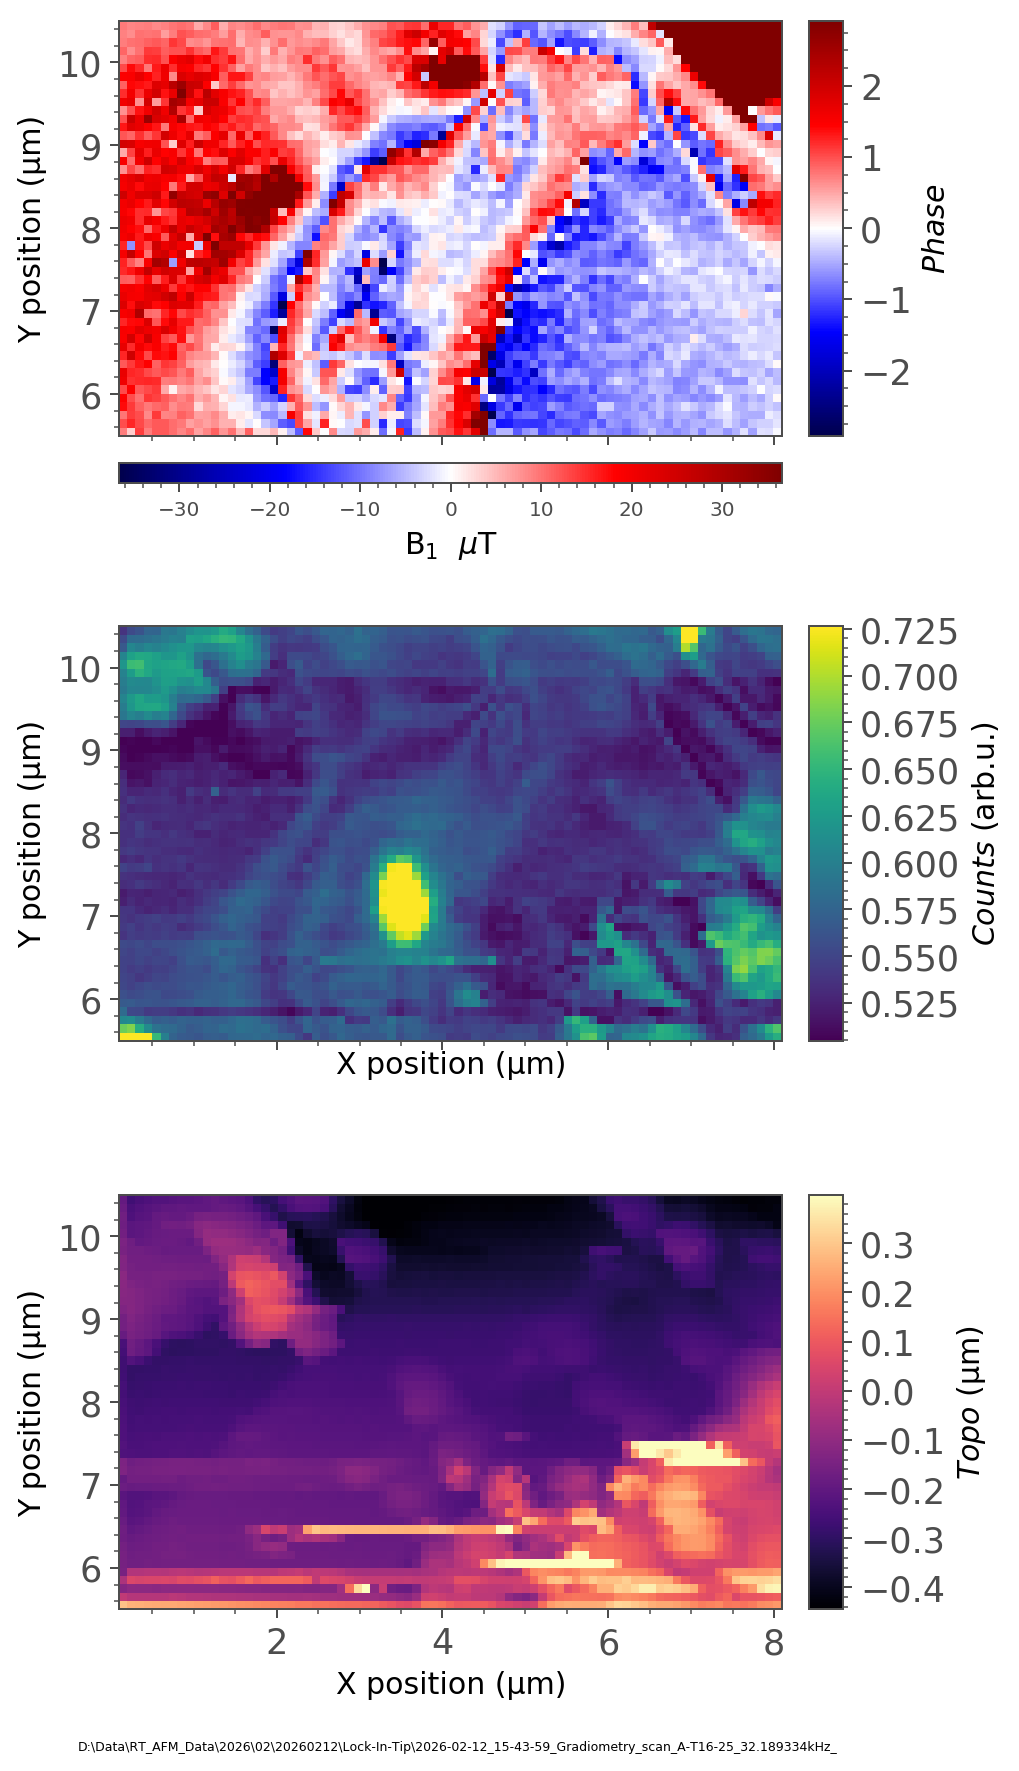

In [11]:
#Plot analysed Data from PODMR
x = data[key]["scan_array_x"]*1e6
y = data[key]["scan_array_y"]*1e6

fig, axs = plt.subplots(3,1, gridspec_kw={"height_ratios": [1.05, 1, 1]}, sharex=True)
#plt.title("Low current - 3us tau")
plt.rcParams['figure.figsize'] = (5, 10)
plt.tight_layout()
fontsize = 12

low_centile = 95
high_centile = 5

d = phase_nom
d = unwrap_phase(phase_nom) 

ker = 0
ker = 3
#d = cv.GaussianBlur(d,(ker,ker),0)

#d = phase_nom
d = unwrap_phase(d) # before phase_nom instead of d

im = axs[0].pcolormesh(x,y,d,cmap=plt.cm.get_cmap('seismic'), vmin=np.nanpercentile(d, low_centile), 
                       vmax=np.nanpercentile(d, low_centile)*-1)

if B1_data == True:
    f_TF = data[key]["Res_freq"]
    B1 = d / (2*np.pi*28e9) / (2*np.sin(np.pi*f_TF*data[key]["tau"]/2)**2) * np.pi*f_TF
    d = B1 * 1e6
    im2 = axs[0].pcolormesh(x,y,d,cmap=plt.cm.get_cmap('seismic'), vmin=np.nanpercentile(d, low_centile), 
                            vmax=np.nanpercentile(d, low_centile)*-1)
    np.savetxt(path + '_B1.txt', d)
else:
    f_TF = data[key]["Res_freq"]
    B2 = d / (2*np.pi*28e9) / (2*np.sin(np.pi*f_TF*data[key]["tau"]/2)**2) * np.pi*f_TF * np.sin(np.pi*f_TF*data[key]["tau"])
    d = B2 * 1e6
    im2 = axs[0].pcolormesh(x,y,d,cmap=plt.cm.get_cmap('seismic'), vmin=np.nanpercentile(d, low_centile), 
                            vmax=np.nanpercentile(d, low_centile)*-1)


axs[0].set_ylabel('Y position (\u03BCm)',fontsize = fontsize)
axs[0].set_aspect('equal')

divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label(label='$Phase$', size=fontsize)

# Second colorbar (Optional: Different colormap)
cax2 = divider.append_axes("bottom", size="5%", pad=0.15)  # Adjust pad for spacing
cbar2 = plt.colorbar(im2, cax=cax2, orientation="horizontal")
cbar2.ax.tick_params(labelsize=fontsize/1.5)
label = 'B$_1$  $\mu$T' if B1_data else 'B$_2$  $\mu$T'
cbar2.set_label(label=label, size=fontsize)

#################### Counts plot
low_centile = 1
high_centile = 99
d = counts/counts.max()
im = axs[1].pcolormesh(x,y,d,cmap=plt.cm.get_cmap('viridis'), vmin=np.nanpercentile(d, low_centile), 
                       vmax=np.nanpercentile(d, high_centile))

axs[1].set_xlabel('X position (\u03BCm)',fontsize = fontsize)
axs[1].set_ylabel('Y position (\u03BCm)',fontsize = fontsize)

axs[1].set_aspect('equal')

divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(label='$Counts$ (arb.u.)', size=fontsize)

#################### Topo plot
low_centile = 1
high_centile = 99
tilt_correct = True

d = (topo_arr - np.max(topo_arr)) *-1e6
if tilt_correct == True:
    fit_para_x = np.polyfit(x, d[0,:], 1)
    fit_para_y = np.polyfit(y[3:], d[3:,0], 1)
    d_correct = d.copy()
    d_correct = d_correct-fit_para_x[0]*x#-fit_para_x[1]
    d_correct = d_correct.transpose()-fit_para_y[0]*y#-fit_para_y[1]
    d = d_correct.transpose()

im = axs[2].pcolormesh(x,y,d,cmap=plt.cm.get_cmap('magma'), vmin=np.nanpercentile(d, low_centile), 
                       vmax=np.nanpercentile(d, high_centile))

axs[2].set_xlabel('X position (\u03BCm)',fontsize = fontsize)
axs[2].set_ylabel('Y position (\u03BCm)',fontsize = fontsize)

axs[2].set_aspect('equal')

divider = make_axes_locatable(axs[2])
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(label='$Topo$ (µm)', size=fontsize)

fig.suptitle(f'{path}', fontsize=5, y=0.0)
path_label = '_B1.png' if B1_data else '_B2.png'
if ker!=0:
    path_label = '_filt'+path_label
plt.savefig(path+path_label, dpi=900, bbox_inches="tight")
plt.show()

In [27]:
fit_para_x = np.polyfit(x, d[0,:], 1)
fit_para_y = np.polyfit(y, d[:,0], 1)
d_correct = d.copy()
d_correct = d_correct-fit_para_x[0]*x-fit_para_x[1]
d_correct = d_correct.transpose()-fit_para_y[0]*y-fit_para_y[1]

plt.pcolormesh(x,y,d_correct.transpose())
plt.colorbar()
plt.show()

In [110]:
fit_para

array([-0.03307924,  0.69183661])

In [117]:
d_correct

array([[ 0.03824864,  0.03111496,  0.02127568, ...,  0.08810276,
         0.03910608,  0.0249242 ],
       [-0.02846076, -0.02398944,  0.00611148, ...,  0.03356716,
         0.00970328,  0.022788  ],
       [-0.03529516, -0.04812484, -0.02685192, ..., -0.02673444,
        -0.01307972, -0.0043368 ],
       ...,
       [ 0.00841844,  0.03702436,  0.06498948, ...,  0.08511276,
         0.09029528,  0.0913486 ],
       [ 0.02764084,  0.02499236,  0.02996128, ...,  0.12647616,
         0.15643468,  0.110785  ],
       [ 0.05113564,  0.05831136,  0.04590928, ...,  0.14171196,
         0.13400828,  0.1257356 ]])

In [61]:
topo_arr.max()

5.8050648e-06

### Fit of oscillation amplitude

In [55]:
# Load B0 
B0 = np.loadtxt(r'D:\Data\RT_AFM_Data\2025\03\20250317\AttoDRY2200_Pi3_SPM\20250317-1855-00_scan1___A-P16-24_QAFM_jupyter_corrected_field.txt')
# Load B1
B1 = np.loadtxt(r'D:\Data\RT_AFM_Data\2025\03\20250318\Lock-In-Tip\2025-03-18_08-19-00_Gradiometry_scan_A-P16-24_195.584032kHz_B1.txt')
B1 = np.flip(B1, axis=0) # B1 has to be flipped to correspond to analyzed B0 data

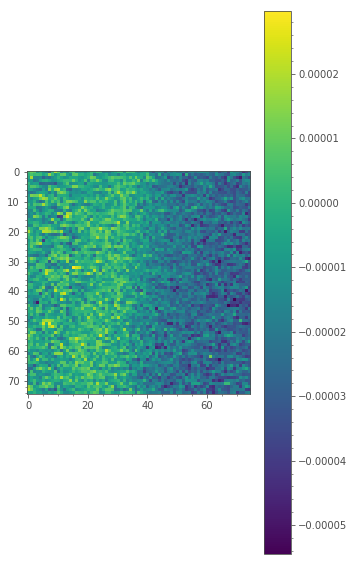

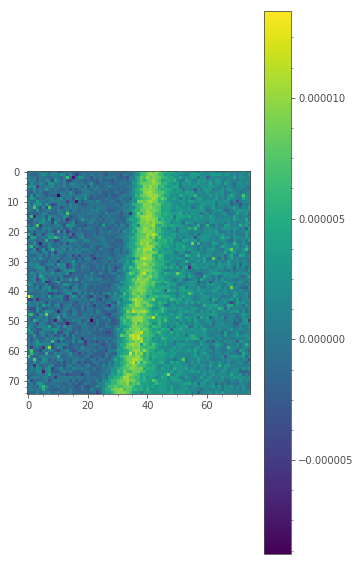

In [122]:
# Quick check if both data sets are flipped correctly, check for units in T
B1 = B1/1000000
plt.imshow(B0)
plt.colorbar()
plt.show()
plt.imshow(B1)
plt.colorbar()
plt.show()

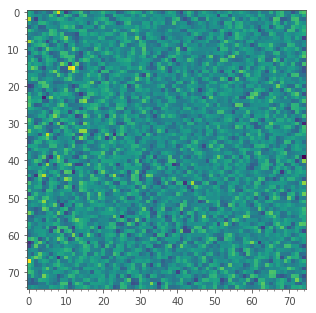

In [123]:
B0_grad = np.gradient(B0, axis=0)
plt.imshow(B0_grad)
plt.show()

In [199]:
from scipy.optimize import minimize
from scipy import ndimage

def cost(variables, B0, B1, stepsize_0):
    x_osc = variables[0]
    alpha = variables[1]
    sigma_0_d = ndimage.standard_deviation(B0)/np.sqrt(2)/stepsize_0
    sigma_0_d = 1000 # T/nm
    sigma_1 = ndimage.standard_deviation(B1)
    sigma_1 = 0.0000001 # T
    
    return (np.sum((B1 - x_osc*(np.cos(alpha)*np.gradient(B0, axis=1) + np.sin(alpha)*np.gradient(B0, axis=0)))**2)/(sigma_1**2 + x_osc**2 * sigma_0_d**2))
    
stepsize_0 = 26.7 # nm
sigma_0_d = ndimage.standard_deviation(B0)/np.sqrt(2)/stepsize_0
sigma_1 = ndimage.standard_deviation(B1)
print(sigma_0_d)
print(sigma_1)

# initial guesses
x_osc_guess = 2 # nm
alpha_guess = 3.14 # rad
# Optimization done here
#x0 = [x_osc_guess, alpha_guess]
x0 = [x_osc_guess, alpha_guess]
res = minimize(cost, x0, args=(B0, B1, stepsize_0), method='Nelder-Mead', tol=1e-6)
res.x
# def x_osc():
#     A = 
#     B =
#     C =
    
#     return (-1*B + np.sqrt(B**2 - 4*A*C))/2*A

array([6.9910704 , 3.09788989])

3.6633399692834775e-07
3.1069114427404437e-06


In [69]:
# little working example
from scipy.optimize import minimize

def cost(x):#(B0, B1, alpha, sigma_0, sigma_1):
    return x**2

# Optimization done here
x0 = 20
res = minimize(cost, x0, method='Nelder-Mead', tol=1e-6)
res.x

array([0.])

#### Control of Keithley 6487

In [61]:
import pyvisa
def _ask(gpib_connection, question):
    """ Ask wrapper.

    @param str question: a question to the device

    @return: the received answer
    """
    return gpib_connection.query(question)

def _write(gpib_connection, command, wait=True):
    """ Write wrapper.

    @param str command: a command to the device
    @param bool wait: optional, is the wait statement should be skipped.

    @return: str: the statuscode of the write command.
    """
    statuscode = gpib_connection.write(command)
    if wait:
        gpib_connection.write('*WAI')
    return statuscode

def _command_wait(gpib_connection, command_str):
    """
    Writes the command in command_str via ressource manager and waits until the device has finished
    processing it.

    @param command_str: The command to be written
    """
    gpib_connection.write(command_str)
    gpib_connection.write('*WAI')
    while int(float(gpib_connection.query('*OPC?'))) != 1:
        time.sleep(0.02)
    return
rm = pyvisa.ResourceManager()
rm.list_resources()

('TCPIP0::rssgs100a113949::hislip0::INSTR', 'TCPIP0::rssgs100a113949::inst0::INSTR', 'ASRL1::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'GPIB0::25::INSTR', 'GPIB0::28::INSTR')

In [62]:
keithley = rm.open_resource('GPIB0::25::INSTR')

In [94]:
keithley.close()

In [63]:
_ask(keithley, ':SOUR:VOLT:STAT?')

'0\n'

In [64]:
_ask(keithley, ':SOUR:VOLT:LEV:IMM:AMPL?')

'0.000000E+00\n'

In [72]:
# To set a constant voltage
voltage = 0.15 # V
_write(keithley, f':SOUR:VOLT:LEV:IMM:AMPL {voltage}')

(30, <StatusCode.success: 0>)